# Feature Transformation — Titanic Dataset

This notebook continues from `titanic_feature_extracted.csv`.

Feature Transformation changes the representation or distribution of existing features.

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

## 2. Load the Dataset

If `Dataset` is at the `03-Data-Preprocessing` level:

```text
03-Data-Preprocessing/
├── Dataset/
│   └── titanic_feature_extracted.csv
└── 05-Feature-Engineering/
    └── 03-Feature-Transformation/
        └── Feature-Transformation.ipynb
```

In [ ]:
df = pd.read_csv('../../Dataset/05_titanic_feature_extracted.csv')
df.head()

,Fare,Age,Pclass,SibSp,Parch,Sex_male,Embarked_Q,Embarked_S,Survived,FamilySize,IsAlone,Title,TicketGroupSize
0,-0.312011,-0.565736,1.0,0.125,0.0,1.0,0.0,1.0,0,1.125,0,Mr,1
1,2.461242,0.663861,0.0,0.125,0.0,0.0,0.0,0.0,1,1.125,0,Mrs,1
2,-0.282777,-0.258337,1.0,0.000,0.0,0.0,0.0,1.0,1,1.000,1,Miss,1
3,1.673732,0.433312,0.0,0.125,0.0,0.0,0.0,1.0,1,1.125,0,Mrs,2
4,-0.277363,0.433312,1.0,0.000,0.0,1.0,0.0,1.0,0,1.000,1,Mr,1


## 3. Inspect the Dataset

In [3]:
print('Shape:', df.shape)
print('\nColumns:')
print(df.columns.tolist())
print('\nData types:')
print(df.dtypes)

Shape: (891, 13)

Columns:
['Fare', 'Age', 'Pclass', 'SibSp', 'Parch', 'Sex_male', 'Embarked_Q', 'Embarked_S', 'Survived', 'FamilySize', 'IsAlone', 'Title', 'TicketGroupSize']

Data types:
Fare               float64
Age                float64
Pclass             float64
SibSp              float64
Parch              float64
Sex_male           float64
Embarked_Q         float64
Embarked_S         float64
Survived             int64
FamilySize         float64
IsAlone              int64
Title                  str
TicketGroupSize      int64
dtype: object


## 4. What Is Feature Transformation?

Feature Transformation changes the representation of an existing feature.

```text
Existing Feature
      ↓
Transformation
      ↓
New Representation
```

Common examples:

- Log transformation
- Binning / discretization
- Square-root transformation

**Difference:**

```text
Feature Selection  → Choose existing features
Feature Extraction → Create new features
Feature Transformation → Change feature representation
```

## 5. Log Transformation

`Fare` is strongly right-skewed. A common transformation is:

\[
x' = \log(1+x)
\]

`log1p()` is used so that zero values can be handled safely.

In [4]:
df_transformed = df.copy()

df_transformed['Log_Fare'] = np.log1p(df_transformed['Fare'])

df_transformed[['Fare', 'Log_Fare']].head()

,Fare,Log_Fare
0,-0.312011,-0.373982
1,2.461242,1.241628
2,-0.282777,-0.332368
3,1.673732,0.983475
4,-0.277363,-0.324848


## 6. Compare Fare Before and After

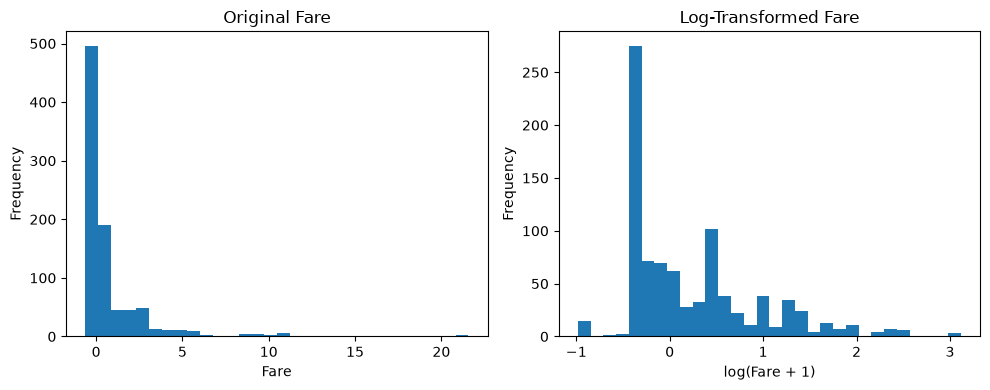

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].hist(df_transformed['Fare'], bins=30)
axes[0].set_title('Original Fare')
axes[0].set_xlabel('Fare')
axes[0].set_ylabel('Frequency')

axes[1].hist(df_transformed['Log_Fare'], bins=30)
axes[1].set_title('Log-Transformed Fare')
axes[1].set_xlabel('log(Fare + 1)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## 7. Binning / Discretization

Binning converts a continuous feature into meaningful groups.

For `Age`:

```text
0–12    → Child
13–18   → Teen
19–35   → Young Adult
36–60   → Adult
61+     → Senior
```

In [6]:
age_bins = [0, 12, 18, 35, 60, 100]
age_labels = ['Child', 'Teen', 'Young Adult', 'Adult', 'Senior']

df_transformed['Age_Group'] = pd.cut(
    df_transformed['Age'],
    bins=age_bins,
    labels=age_labels,
    include_lowest=True
)

df_transformed[['Age', 'Age_Group']].head(10)

,Age,Age_Group
0,-0.565736,NaN
1,0.663861,Child
2,-0.258337,NaN
3,0.433312,Child
4,0.433312,Child
5,-0.104637,NaN
6,1.893459,Child
7,-2.102733,NaN
8,-0.181487,NaN
9,-1.180535,NaN


## 8. Check the Age Groups

In [7]:
df_transformed['Age_Group'].value_counts().sort_index()

Age_Group
Child          330
Teen             0
Young Adult      0
Adult            0
Senior           0
Name: count, dtype: int64

## 9. Square-Root Transformation

Another simple mathematical transformation is:

\[
x' = \sqrt{x}
\]

We can apply it to `Fare`.

In [8]:
df_transformed['Sqrt_Fare'] = np.sqrt(df_transformed['Fare'])

df_transformed[['Fare', 'Sqrt_Fare']].head()

d:\Code\Machine_Learning\.venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


,Fare,Sqrt_Fare
0,-0.312011,NaN
1,2.461242,1.568835
2,-0.282777,NaN
3,1.673732,1.293728
4,-0.277363,NaN


## 10. Review the New Features

We created:

```text
Log_Fare
Age_Group
Sqrt_Fare
```

In [9]:
new_features = ['Log_Fare', 'Age_Group', 'Sqrt_Fare']

df_transformed[new_features].head(10)

,Log_Fare,Age_Group,Sqrt_Fare
0,-0.373982,NaN,NaN
1,1.241628,Child,1.568835
2,-0.332368,NaN,NaN
3,0.983475,Child,1.293728
4,-0.324848,Child,NaN
5,-0.300672,NaN,NaN
6,0.963226,Child,1.272846
7,0.252115,NaN,0.535485
8,-0.155282,NaN,NaN
9,0.516617,NaN,0.822404


## 11. Choosing a Transformation

Do not automatically keep every transformed feature.

Compare the original and transformed versions using:

- Distribution / skewness
- Model performance
- Feature redundancy
- Interpretability

The best transformation is the one that is useful for the ML problem.

## 12. Final Verification

In [10]:
print('Shape:', df_transformed.shape)

print('\nMissing values:')
print(df_transformed.isnull().sum())

print('\nColumns:')
print(df_transformed.columns.tolist())

Shape: (891, 16)

Missing values:
Fare                 0
Age                  0
Pclass               0
SibSp                0
Parch                0
Sex_male             0
Embarked_Q           0
Embarked_S           0
Survived             0
FamilySize           0
IsAlone              0
Title                0
TicketGroupSize      0
Log_Fare             0
Age_Group          561
Sqrt_Fare          440
dtype: int64

Columns:
['Fare', 'Age', 'Pclass', 'SibSp', 'Parch', 'Sex_male', 'Embarked_Q', 'Embarked_S', 'Survived', 'FamilySize', 'IsAlone', 'Title', 'TicketGroupSize', 'Log_Fare', 'Age_Group', 'Sqrt_Fare']


## Applying One - Hot Encoding on Final(df_transformed) Dataset 

In [13]:
from sklearn.preprocessing import OneHotEncoder

categorical_features = ["Title", "Age_Group"]

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

encoded = encoder.fit_transform(
    df_transformed[categorical_features]
)

encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(categorical_features),
    index=df_transformed.index
)

# Remove original categorical columns and add encoded columns
df_transformed = pd.concat(
    [
        df_transformed.drop(columns=categorical_features),
        encoded_df
    ],
    axis=1
)

df_transformed.head()

,Fare,Age,Pclass,SibSp,Parch,Sex_male,Embarked_Q,Embarked_S,Survived,FamilySize,IsAlone,TicketGroupSize,Log_Fare,Sqrt_Fare,Title_Capt,Title_Col,Title_Don,Title_Dr,Title_Jonkheer,Title_Lady,Title_Major,Title_Master,Title_Miss,Title_Mlle,Title_Mme,Title_Mr,Title_Mrs,Title_Ms,Title_Rev,Title_Sir,Title_the Countess,Age_Group_Child,Age_Group_nan
0,-0.312011,-0.565736,1.0,0.125,0.0,1.0,0.0,1.0,0,1.125,0,1,-0.373982,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,2.461242,0.663861,0.0,0.125,0.0,0.0,0.0,0.0,1,1.125,0,1,1.241628,1.568835,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,-0.282777,-0.258337,1.0,0.000,0.0,0.0,0.0,1.0,1,1.000,1,1,-0.332368,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,1.673732,0.433312,0.0,0.125,0.0,0.0,0.0,1.0,1,1.125,0,2,0.983475,1.293728,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,-0.277363,0.433312,1.0,0.000,0.0,1.0,0.0,1.0,0,1.000,1,1,-0.324848,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


## 13. Save the Final Dataset

```text
Feature Selection
        ↓
Feature Extraction
        ↓
Feature Transformation
        ↓
titanic_feature_engineered.csv
```

In [ ]:
output_path = '../../Dataset/06_titanic_feature_engineered.csv'

df_transformed.to_csv(output_path, index=False)

print(f'Saved: {output_path}')

Saved: ../../Dataset/titanic_feature_engineered.csv


## Key Takeaways

- Feature Transformation changes the representation of existing features.
- Log transformation can help reduce strong right skew.
- `np.log1p()` safely handles zero values.
- Binning converts continuous values into meaningful groups.
- Mathematical transformations such as square root provide alternative representations.
- Do not keep every transformed feature automatically; evaluate whether it helps the model.

### Feature Engineering Complete

```text
Feature Selection
        ↓
Feature Extraction
        ↓
Feature Transformation
        ↓
titanic_feature_engineered.csv
```